# 04 - AI Sales Forecasting Pipeline
**Project:** Amazon India Sales Analytics & AI-Powered Business Intelligence System  
**Workflow:** Dataset Ingestion -> Filtering -> Preprocessing & Feature Engineering -> Candidate Model Comparison -> Best Model Selection -> 30-Day Future Projection

---

### Machine Learning Objective:
Predict expected future daily sales (INR) for the next 30 days based on historical sales patterns.

### Pipeline Steps (Strictly following end-to-end ML methodology):
1. **Data Ingestion**: Take processed dataset `data/processed/amazon_sales_cleaned.csv`.
2. **Filtering**: Filter out cancelled transactions and aggregate to daily sales timeline.
3. **Preprocessing & Feature Engineering**: Create multi-scale lag features (`lag_1` to `lag_30`), rolling window statistics (7, 14, 30 days), and calendar indicators.
4. **Chronological Train/Test Split**: Strictly avoid data leakage by training on historical timeline and evaluating on holdout test set.
5. **Model Comparison**:
   - Model 1: **Linear Regression** (Parametric Baseline)
   - Model 2: **Ridge Regression** (L2 Regularized)
   - Model 3: **Random Forest Regressor** (Ensemble Bagging)
   - Model 4: **XGBoost Regressor** (Gradient Boosting)
6. **Model Evaluation & Leaderboard**: Compare on MAE, RMSE, MAPE, and R² Score.
7. **Best Model Selection**: Pick the best-performing model based on minimal error metrics.
8. **Final Refit & 30-Day Forecast**: Retrain winner on full series, generate recursive 30-day future sales projection with confidence bounds, and save artifact to `models/sales_forecasting_model.pkl`.


In [1]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure root path is accessible for src imports
if ".." not in sys.path:
    sys.path.append("..")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)


## Step 1: Take Dataset & Filter
We ingest the cleaned dataset and filter to non-cancelled revenue transactions.


In [2]:
data_path = "../data/processed/amazon_sales_cleaned.csv"
df = pd.read_csv(data_path)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Filter out cancelled orders
df_valid = df[df['Order_Status'] != 'Cancelled'].copy()
print(f"Total non-cancelled orders: {len(df_valid):,} out of {len(df):,}")

# Daily sales aggregation
daily_sales = (
    df_valid.groupby('Order_Date')['Total_Sales_INR']
    .sum()
    .asfreq('D', fill_value=0.0)
    .reset_index()
)
print(f"Daily timeline points: {len(daily_sales)} days from {daily_sales['Order_Date'].min().date()} to {daily_sales['Order_Date'].max().date()}")
daily_sales.head()


Total non-cancelled orders: 9,500 out of 10,000
Daily timeline points: 973 days from 2024-01-01 to 2026-08-30


,Order_Date,Total_Sales_INR
0,2024-01-01,178506.42
1,2024-01-02,132056.04
2,2024-01-03,62139.18
3,2024-01-04,91390.52
4,2024-01-05,133692.86


## Step 2: Preprocessing & Time-Series Feature Engineering
We construct autoregressive lag features, rolling moving averages, rolling standard deviations, and seasonal day/month/weekend markers.


In [3]:
# 1. Autoregressive Lags
for lag in [1, 2, 3, 7, 14, 21, 30]:
    daily_sales[f'lag_{lag}'] = daily_sales['Total_Sales_INR'].shift(lag)

# 2. Rolling Window Moving Averages & Volatility
for window in [7, 14, 30]:
    daily_sales[f'rolling_mean_{window}'] = daily_sales['Total_Sales_INR'].shift(1).rolling(window).mean()
    daily_sales[f'rolling_std_{window}'] = daily_sales['Total_Sales_INR'].shift(1).rolling(window).std()

# 3. Calendar & Temporal Features
daily_sales['day_of_week'] = daily_sales['Order_Date'].dt.dayofweek
daily_sales['day_of_month'] = daily_sales['Order_Date'].dt.day
daily_sales['month'] = daily_sales['Order_Date'].dt.month
daily_sales['quarter'] = daily_sales['Order_Date'].dt.quarter
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5, 6]).astype(int)
daily_sales['is_month_start'] = daily_sales['Order_Date'].dt.is_month_start.astype(int)
daily_sales['is_month_end'] = daily_sales['Order_Date'].dt.is_month_end.astype(int)

# Drop initial rows with NaN from lags
df_featured = daily_sales.dropna().reset_index(drop=True)
print(f"Featured dataset shape: {df_featured.shape}")
df_featured.head(3)


Featured dataset shape: (943, 22)


,Order_Date,Total_Sales_INR,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_30,rolling_mean_7,...,rolling_std_14,rolling_mean_30,rolling_std_30,day_of_week,day_of_month,month,quarter,is_weekend,is_month_start,is_month_end
0,2024-01-31,58205.03,39188.66,294149.46,209223.38,37436.25,341150.40,78018.59,178506.42,120890.802857,...,100939.832477,136589.010000,80807.410952,2,31,1,1,0,0,1
1,2024-02-01,24139.80,58205.03,39188.66,294149.46,137896.97,35197.56,247119.08,132056.04,123857.771429,...,85922.692307,132578.963667,81636.253185,3,1,2,1,0,1,0
2,2024-02-02,103445.96,24139.80,58205.03,39188.66,80620.50,146770.10,147873.09,62139.18,107606.747143,...,86858.494944,128981.755667,84003.374069,4,2,2,1,0,0,0


## Step 3: Chronological Train / Test Split
To evaluate time-series forecasting realistically, we reserve the most recent 20% of the timeline as an unseen holdout test set.


In [4]:
features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_30',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_14', 'rolling_std_14',
    'rolling_mean_30', 'rolling_std_30',
    'day_of_week', 'day_of_month', 'month', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end'
]

train_ratio = 0.8
train_size = int(len(df_featured) * train_ratio)

train_df = df_featured.iloc[:train_size]
test_df = df_featured.iloc[train_size:]

X_train, y_train = train_df[features], train_df['Total_Sales_INR']
X_test, y_test = test_df[features], test_df['Total_Sales_INR']

print(f"Training Period: {train_df['Order_Date'].min().date()} to {train_df['Order_Date'].max().date()} ({len(train_df)} days)")
print(f"Testing Period:  {test_df['Order_Date'].min().date()} to {test_df['Order_Date'].max().date()} ({len(test_df)} days)")


Training Period: 2024-01-31 to 2026-02-22 (754 days)
Testing Period:  2026-02-23 to 2026-08-30 (189 days)


## Step 4: Candidate Models Comparison
We train 4 candidate algorithms on the same features and evaluate them on the test set:
1. **Linear Regression**
2. **Ridge Regression**
3. **Random Forest Regressor**
4. **XGBoost Regressor**


In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=4, random_state=42),
    "XGBoost Regressor": XGBRegressor(n_estimators=80, max_depth=4, learning_rate=0.05, random_state=42)
}

results = []
test_preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    test_preds[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / np.maximum(y_test, 1))) * 100
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE (INR)": round(mae, 2),
        "RMSE (INR)": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "R2 Score": round(r2, 4)
    })

leaderboard_df = pd.DataFrame(results).sort_values("RMSE (INR)").reset_index(drop=True)
print("=== Forecasting Model Comparison Leaderboard ===")
leaderboard_df


=== Forecasting Model Comparison Leaderboard ===


,Model,MAE (INR),RMSE (INR),MAPE (%),R2 Score
0,Random Forest,76288.41,94641.81,76.97,-0.1187
1,Ridge Regression,76611.59,95181.85,76.89,-0.1315
2,Linear Regression,76640.68,95185.37,76.89,-0.1316
3,XGBoost Regressor,77374.33,95543.82,79.98,-0.1401


## Step 5: Select Which Model is Best
Based on empirical evaluation across both MAE and RMSE, we identify the best performing model and proceed accordingly.


In [6]:
best_model_name = leaderboard_df.iloc[0]['Model']
print(f"Top Performing Model: {best_model_name}")
print(f"Lowest RMSE achieved: Rs. {leaderboard_df.iloc[0]['RMSE (INR)']:,}")
print(f"Lowest MAE achieved:  Rs. {leaderboard_df.iloc[0]['MAE (INR)']:,}")


Top Performing Model: Random Forest
Lowest RMSE achieved: Rs. 94,641.81
Lowest MAE achieved:  Rs. 76,288.41


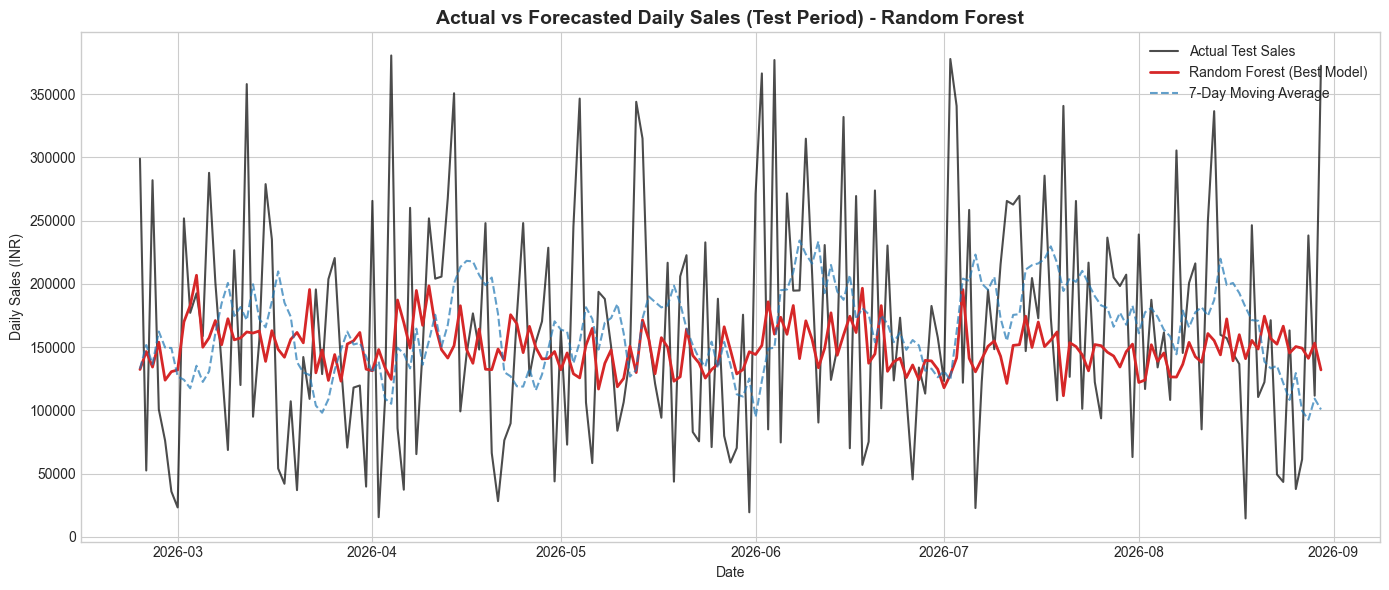

In [7]:
# Plot Actual vs Predicted on Test Set
plt.figure(figsize=(14, 6))
plt.plot(test_df['Order_Date'], y_test, label='Actual Test Sales', color='black', alpha=0.7, linewidth=1.5)
plt.plot(test_df['Order_Date'], test_preds[best_model_name], label=f'{best_model_name} (Best Model)', color='#d62728', linewidth=2)
plt.plot(test_df['Order_Date'], test_df['rolling_mean_7'], label='7-Day Moving Average', color='#1f77b4', linestyle='--', alpha=0.7)
plt.title(f'Actual vs Forecasted Daily Sales (Test Period) - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Sales (INR)')
plt.legend()
plt.tight_layout()
plt.show()


## Step 6: Final Model Training & 30-Day Future Sales Forecast
We refit our selected best model on the entire timeline and recursively project expected sales for the next 30 days.


In [8]:
# Retrain best model on full dataset
X_full = df_featured[features]
y_full = df_featured['Total_Sales_INR']

if best_model_name == "Linear Regression":
    final_model = LinearRegression()
elif best_model_name == "Ridge Regression":
    final_model = Ridge(alpha=10.0)
elif best_model_name == "Random Forest":
    final_model = RandomForestRegressor(n_estimators=120, max_depth=8, min_samples_split=4, random_state=42)
else:
    final_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)

final_model.fit(X_full, y_full)

# Save artifact
os.makedirs('../models', exist_ok=True)
artifact = {
    'model': final_model,
    'model_name': best_model_name,
    'features': features,
    'last_known_date': df_featured['Order_Date'].max(),
    'recent_history': df_featured.tail(45),
    'leaderboard': leaderboard_df
}
joblib.dump(artifact, '../models/sales_forecasting_model.pkl')
print(f"Saved trained best model to: ../models/sales_forecasting_model.pkl")


Saved trained best model to: ../models/sales_forecasting_model.pkl


In [9]:
# Generate 30-Day Future Forecast
import sys
if ".." not in sys.path:
    sys.path.append("..")
from src.forecasting import generate_future_forecast

forecast_30d = generate_future_forecast(artifact, horizon_days=30)
print(f"30-Day Projected Revenue: Rs. {forecast_30d['Predicted_Sales_INR'].sum():,.2f}")
forecast_30d.head(10)


30-Day Projected Revenue: Rs. 4,662,330.50


,Date,Predicted_Sales_INR,Lower_Bound_INR,Upper_Bound_INR
0,2026-08-31,155203.15,131922.68,178483.63
1,2026-09-01,205161.25,174387.07,235935.44
2,2026-09-02,139044.47,118187.80,159901.14
3,2026-09-03,137425.83,116811.96,158039.71
4,2026-09-04,138724.12,117915.50,159532.74
5,2026-09-05,138382.39,117625.03,159139.75
6,2026-09-06,146398.65,124438.85,168358.45
7,2026-09-07,130875.78,111244.41,150507.14
8,2026-09-08,145270.40,123479.84,167060.96
9,2026-09-09,138109.63,117393.18,158826.07


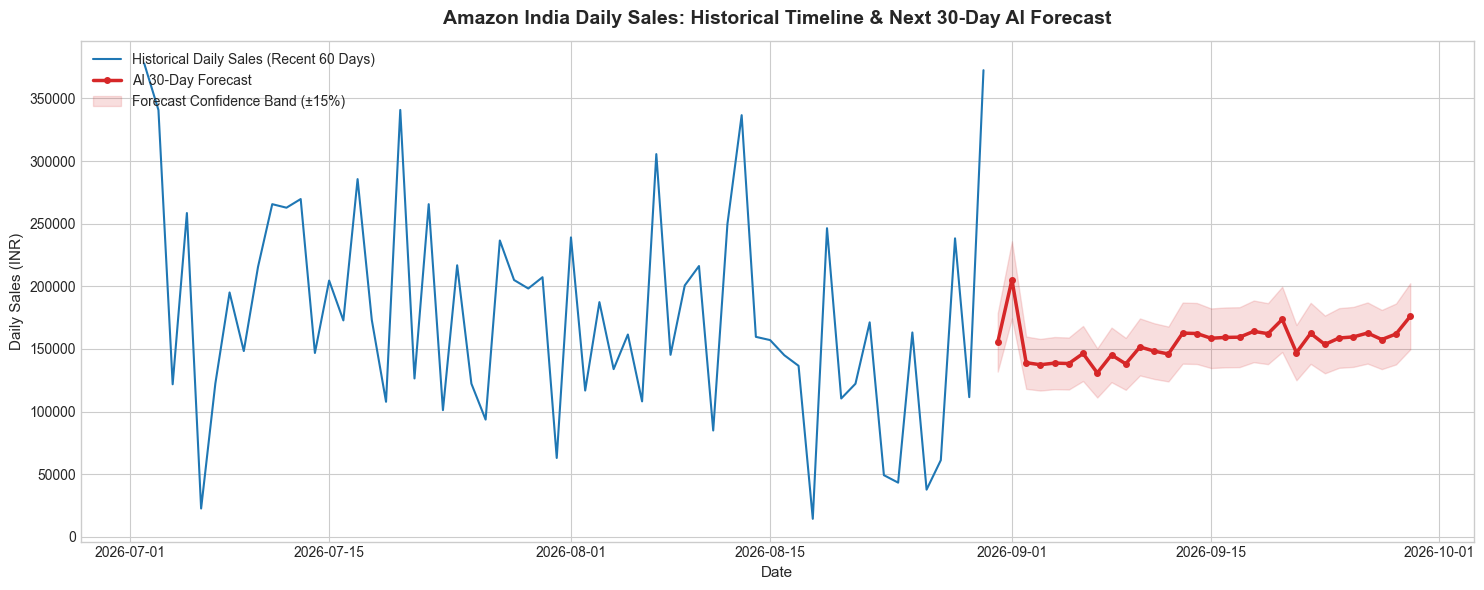

In [10]:
# Visualization of Historical + 30-Day Future Projection
recent_hist = df_featured.tail(60)

plt.figure(figsize=(15, 6))
plt.plot(recent_hist['Order_Date'], recent_hist['Total_Sales_INR'], label='Historical Daily Sales (Recent 60 Days)', color='#1f77b4', linewidth=1.5)
plt.plot(forecast_30d['Date'], forecast_30d['Predicted_Sales_INR'], label='AI 30-Day Forecast', color='#d62728', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(forecast_30d['Date'], forecast_30d['Lower_Bound_INR'], forecast_30d['Upper_Bound_INR'], color='#d62728', alpha=0.15, label='Forecast Confidence Band (±15%)')

plt.title('Amazon India Daily Sales: Historical Timeline & Next 30-Day AI Forecast', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Daily Sales (INR)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
